# Tag 07 — Experten
## Oblique Decision Trees & SHAP — Heart Disease

تمرین‌ه نوت‌بوک fallback امن دارد و از LogisticRegression به عنوان مدل oblique-like استفاده می‌کند.ا:
1. مقایسه Oblique Decision Tree با Standard Tree
2. SHAP Summary Plot
3. توضیح یک misclassification با SHAP Waterfall Plot

نکته: اگر `scikit-obliquedecisiontree` نصب نشود، این

In [1]:

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Find project root automatically
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "03_experten"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Output dir:", OUTPUT_DIR)

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


Project root: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\decision-trees-predictive-modeling
Data dir: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\decision-trees-predictive-modeling\data
Output dir: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\decision-trees-predictive-modeling\outputs\03_experten


In [2]:

heart_path = DATA_DIR / "heart.csv"
if not heart_path.exists():
    raise FileNotFoundError(f"Could not find {heart_path}. Put heart.csv into ../data/.")

df = pd.read_csv(heart_path)
X = df.drop(columns=["target"])
y = df["target"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(df.shape)
df.head()


(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 1) Oblique vs Standard Tree

In [3]:

# Standard tree
std_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
std_tree.fit(X_tr, y_tr)

# Try real ObliqueDecisionTreeClassifier. If not available, use LogisticRegression fallback.
oblique_available = False
try:
    from obliquedecisiontree import ObliqueDecisionTreeClassifier as ODT
    oblique_model = ODT(max_depth=5, random_state=42)
    oblique_model.fit(X_tr, y_tr)
    oblique_name = "ObliqueDecisionTreeClassifier"
    oblique_available = True
except Exception as e:
    print("ObliqueDecisionTreeClassifier not available. Using LogisticRegression fallback.")
    print("Reason:", repr(e))
    oblique_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=42))
    oblique_model.fit(X_tr, y_tr)
    oblique_name = "Fallback: StandardScaler + LogisticRegression"

results = pd.DataFrame([
    {"model": "Standard DecisionTree", "test_accuracy": std_tree.score(X_te, y_te), "train_accuracy": std_tree.score(X_tr, y_tr), "depth": std_tree.tree_.max_depth, "node_count": std_tree.tree_.node_count},
    {"model": oblique_name, "test_accuracy": oblique_model.score(X_te, y_te), "train_accuracy": oblique_model.score(X_tr, y_tr), "depth": None, "node_count": None},
])
results.to_csv(OUTPUT_DIR / "expert_oblique_vs_standard.csv", index=False)
results


ObliqueDecisionTreeClassifier not available. Using LogisticRegression fallback.
Reason: ModuleNotFoundError("No module named 'obliquedecisiontree'")


,model,test_accuracy,train_accuracy,depth,node_count
0,Standard DecisionTree,0.786885,0.925620,5.0,41.0
1,Fallback: StandardScaler + LogisticRegression,0.803279,0.842975,NaN,NaN


## 2) SHAP Summary Plot

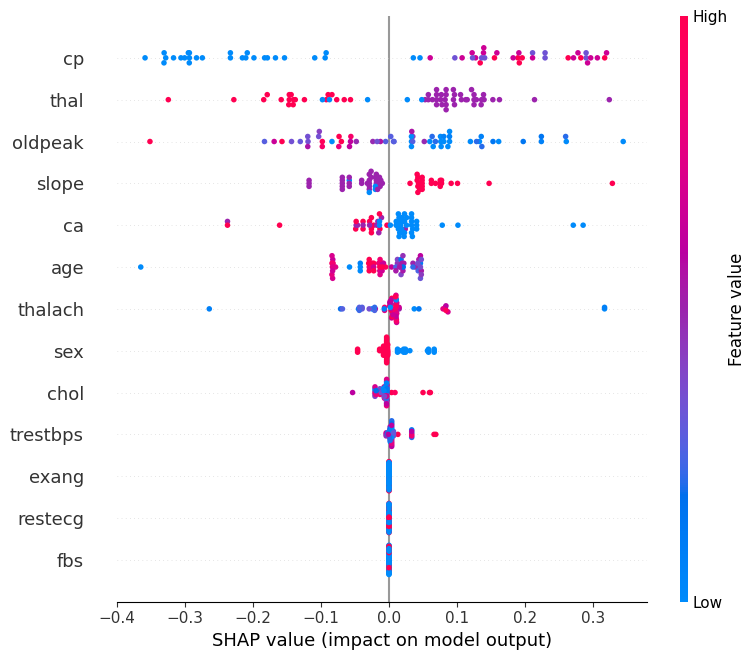

Saved SHAP summary plot.


In [4]:

# SHAP can be version-sensitive. This cell tries a robust path.
try:
    import shap
    explainer = shap.TreeExplainer(std_tree)
    shap_values = explainer.shap_values(X_te)
    
    # For binary classification, shap_values can be list[class] or array.
    if isinstance(shap_values, list):
        sv_for_positive = shap_values[1]
    else:
        sv_for_positive = shap_values
        if sv_for_positive.ndim == 3:
            sv_for_positive = sv_for_positive[:, :, 1]
    
    shap.summary_plot(sv_for_positive, X_te, show=False)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "expert_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved SHAP summary plot.")
except Exception as e:
    print("SHAP summary plot failed. You can still finish Task 1.")
    print("Reason:", repr(e))


## 3) Explain one misclassification

In [5]:

y_pred = std_tree.predict(X_te)
mis_idx = np.where(y_pred != y_te.to_numpy())[0]
print("Number of misclassifications:", len(mis_idx))

if len(mis_idx) > 0:
    i = int(mis_idx[0])
    sample = X_te.iloc[[i]]
    print("Selected test row index:", X_te.index[i])
    print("True label:", y_te.iloc[i], "Predicted:", y_pred[i])
    display(sample)
    sample.to_csv(OUTPUT_DIR / "expert_misclassified_sample.csv", index=False)
else:
    print("No misclassification found on this split. Try changing random_state or max_depth.")


Number of misclassifications: 13
Selected test row index: 179
True label: 0 Predicted: 1


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1


In [6]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "shap"
])

0

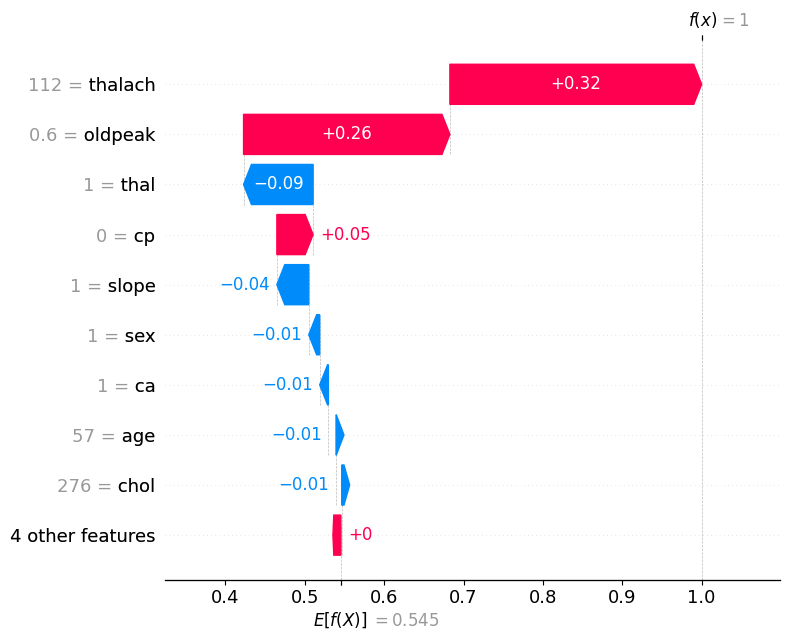

In [7]:

# SHAP waterfall for selected misclassification, if possible.
try:
    import shap
    if len(mis_idx) > 0:
        i = int(mis_idx[0])
        explainer = shap.TreeExplainer(std_tree)
        shap_exp = explainer(X_te)
        
        # Binary classification shape handling
        if len(shap_exp.values.shape) == 3:
            class_id = 1
            exp_i = shap.Explanation(
                values=shap_exp.values[i, :, class_id],
                base_values=shap_exp.base_values[i, class_id],
                data=X_te.iloc[i].values,
                feature_names=X_te.columns.tolist()
            )
        else:
            exp_i = shap_exp[i]
        
        shap.plots.waterfall(exp_i, show=False)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "expert_shap_waterfall_misclassification.png", dpi=150, bbox_inches="tight")
        plt.show()
except Exception as e:
    print("SHAP waterfall failed.")
    print("Reason:", repr(e))


## What to send back

- `expert_oblique_vs_standard.csv`
- `expert_shap_summary.png` اگر ساخته شد
- `expert_misclassified_sample.csv`
- `expert_shap_waterfall_misclassification.png` اگر ساخته شد